# Prodigy InfoTech Data Science Internship

# Task-04: Twitter Sentiment Analysis

## Objective

The objective of this project is to analyze sentiment patterns in social media data to understand public opinion and customer attitudes toward different topics or brands.

## Dataset

Twitter Entity Sentiment Analysis Dataset

## Workflow

1. Import Libraries
2. Load Dataset
3. Data Cleaning
4. Exploratory Data Analysis
5. Feature Engineering
6. Text Vectorization
7. Model Building
8. Model Evaluation
9. Feature Importance
10. Business Insights

In [2]:
# Import Required Libraries


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

# Load Dataset

The Twitter sentiment dataset is loaded into a Pandas DataFrame for further preprocessing and analysis.

In [12]:
# Load Dataset

df = pd.read_csv("C:\\Users\\ASUS\\Downloads\\twitter_training.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [15]:
import pandas as pd

column_names = [
    "ID",
    "Topic",
    "Sentiment",
    "Text"
]

df = pd.read_csv("C:\\Users\\ASUS\\Downloads\\twitter_training.csv",
    header=None,
    names=column_names
)

df.head()

,ID,Topic,Sentiment,Text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [16]:
print(df.columns)

Index(['ID', 'Topic', 'Sentiment', 'Text'], dtype='object')


In [17]:
df.head()

,ID,Topic,Sentiment,Text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [18]:
df.tail()

,ID,Topic,Sentiment,Text
74677,9200,Nvidia,Positive,Just realized that the Windows partition of my...
74678,9200,Nvidia,Positive,Just realized that my Mac window partition is ...
74679,9200,Nvidia,Positive,Just realized the windows partition of my Mac ...
74680,9200,Nvidia,Positive,Just realized between the windows partition of...
74681,9200,Nvidia,Positive,Just like the windows partition of my Mac is l...


In [19]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 74682
Columns : 4


In [20]:
print(df.columns.tolist())

['ID', 'Topic', 'Sentiment', 'Text']


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         74682 non-null  int64 
 1   Topic      74682 non-null  object
 2   Sentiment  74682 non-null  object
 3   Text       73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [22]:
df.describe(include="all")

,ID,Topic,Sentiment,Text
count,74682.000000,74682,74682,73996
unique,NaN,32,4,69491
top,NaN,TomClancysRainbowSix,Negative,"At the same time, despite the fact that there ..."
freq,NaN,2400,22542,172
mean,6432.586165,NaN,NaN,NaN
std,3740.427870,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN
25%,3195.000000,NaN,NaN,NaN
50%,6422.000000,NaN,NaN,NaN
75%,9601.000000,NaN,NaN,NaN


In [23]:
print(df["Sentiment"].unique())

['Positive' 'Neutral' 'Negative' 'Irrelevant']


# Data Cleaning

Before building a machine learning model, we clean the dataset by handling missing values, removing duplicates, and preprocessing the text.

In [24]:
original_shape = df.shape

print(original_shape)

(74682, 4)


In [25]:
df.isnull().sum()

ID             0
Topic          0
Sentiment      0
Text         686
dtype: int64

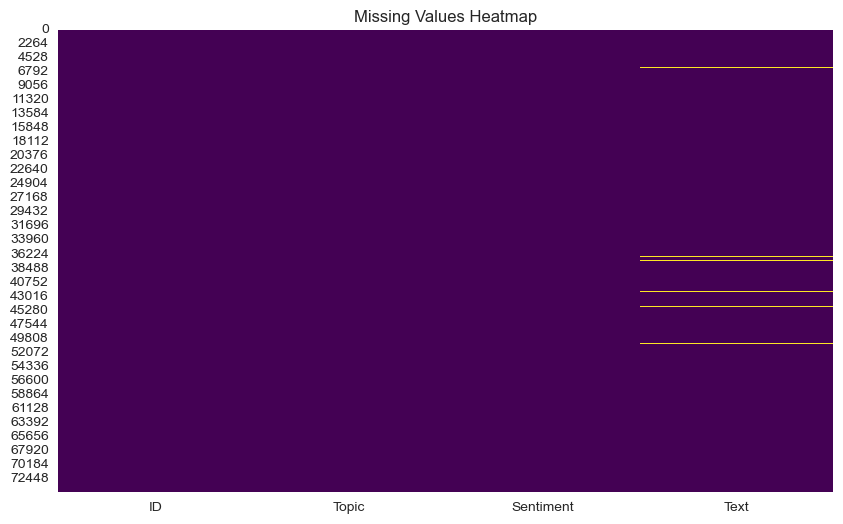

In [26]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")

plt.show()

In [27]:
print("Conclusion:")
print("- The heatmap shows the distribution of missing values.")
print("- Missing text values should be removed before training.")

Conclusion:
- The heatmap shows the distribution of missing values.
- Missing text values should be removed before training.


In [28]:
df = df.dropna()

In [29]:
duplicates = df.duplicated().sum()

print("Duplicate Records :", duplicates)

Duplicate Records : 2340


In [30]:
df = df.drop_duplicates()

In [31]:
print(df.columns)

Index(['ID', 'Topic', 'Sentiment', 'Text'], dtype='object')


In [32]:
if "ID" in df.columns:
    df = df.drop("ID", axis=1)

# Text Cleaning

The tweets are cleaned before feature extraction.

Cleaning steps include:

- Lowercase conversion
- Remove URLs
- Remove @mentions
- Remove hashtags
- Remove punctuation
- Remove numbers
- Remove extra spaces

In [33]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"www\S+", "", text)

    text = re.sub(r"@\w+", "", text)

    text = re.sub(r"#", "", text)

    text = re.sub(r"\d+", "", text)

    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [34]:
df["Clean_Text"] = df["Text"].apply(clean_text)

In [35]:
comparison = pd.DataFrame({

    "Original": df["Text"].head(10),

    "Cleaned": df["Clean_Text"].head(10)

})

comparison

,Original,Cleaned
0,im getting on borderlands and i will murder yo...,im getting on borderlands and i will murder yo...
1,I am coming to the borders and I will kill you...,i am coming to the borders and i will kill you...
2,im getting on borderlands and i will kill you ...,im getting on borderlands and i will kill you all
3,im coming on borderlands and i will murder you...,im coming on borderlands and i will murder you...
4,im getting on borderlands 2 and i will murder ...,im getting on borderlands and i will murder yo...
5,im getting into borderlands and i can murder y...,im getting into borderlands and i can murder y...
6,So I spent a few hours making something for fu...,so i spent a few hours making something for fu...
7,So I spent a couple of hours doing something f...,so i spent a couple of hours doing something f...
8,So I spent a few hours doing something for fun...,so i spent a few hours doing something for fun...
9,So I spent a few hours making something for fu...,so i spent a few hours making something for fu...


In [36]:
print("Conclusion:")
print("- URLs, punctuation, numbers and mentions have been removed.")
print("- Tweets are now standardized for machine learning.")

Conclusion:
- URLs, punctuation, numbers and mentions have been removed.
- Tweets are now standardized for machine learning.


In [37]:
print("Original Shape :", original_shape)

print("Cleaned Shape :", df.shape)

Original Shape : (74682, 4)
Cleaned Shape : (71656, 4)


In [38]:
df.to_csv(
    "cleaned_twitter_sentiment.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [39]:
print("="*60)

print("PART 1 SUMMARY")

print("="*60)

print("Original Dataset :", original_shape)

print("Current Dataset :", df.shape)

print("Missing Values Removed")

print("Duplicate Records Removed")

print("Tweets Successfully Cleaned")

PART 1 SUMMARY
Original Dataset : (74682, 4)
Current Dataset : (71656, 4)
Missing Values Removed
Duplicate Records Removed
Tweets Successfully Cleaned


# 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps us understand the distribution
of sentiments, topics, and tweet characteristics before building
the machine learning model.

We perform:

- Univariate Analysis
- Bivariate Analysis

Each visualization is followed by a short interpretation.

In [40]:
# ==========================================================
# Feature Creation for EDA
# ==========================================================

df["Text_Length"] = df["Clean_Text"].apply(len)

df["Word_Count"] = df["Clean_Text"].apply(lambda x: len(x.split()))

df["Character_Count"] = df["Text"].astype(str).apply(len)

df.head()

,Topic,Sentiment,Text,Clean_Text,Text_Length,Word_Count,Character_Count
0,Borderlands,Positive,im getting on borderlands and i will murder yo...,im getting on borderlands and i will murder yo...,51,10,53
1,Borderlands,Positive,I am coming to the borders and I will kill you...,i am coming to the borders and i will kill you...,50,12,51
2,Borderlands,Positive,im getting on borderlands and i will kill you ...,im getting on borderlands and i will kill you all,49,10,50
3,Borderlands,Positive,im coming on borderlands and i will murder you...,im coming on borderlands and i will murder you...,50,10,51
4,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,im getting on borderlands and i will murder yo...,54,11,57


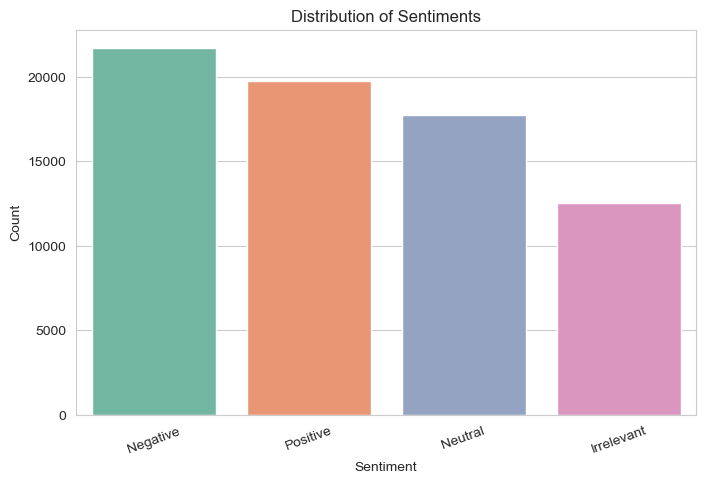

In [41]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Sentiment",
    palette="Set2",
    order=df["Sentiment"].value_counts().index
)

plt.title("Distribution of Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.xticks(rotation=20)

plt.show()

In [42]:
print("Conclusion:")
print("- Positive, Negative, Neutral, and Irrelevant sentiments are distributed across the dataset.")
print("- Some sentiment classes occur much more frequently than others.")

Conclusion:
- Positive, Negative, Neutral, and Irrelevant sentiments are distributed across the dataset.
- Some sentiment classes occur much more frequently than others.


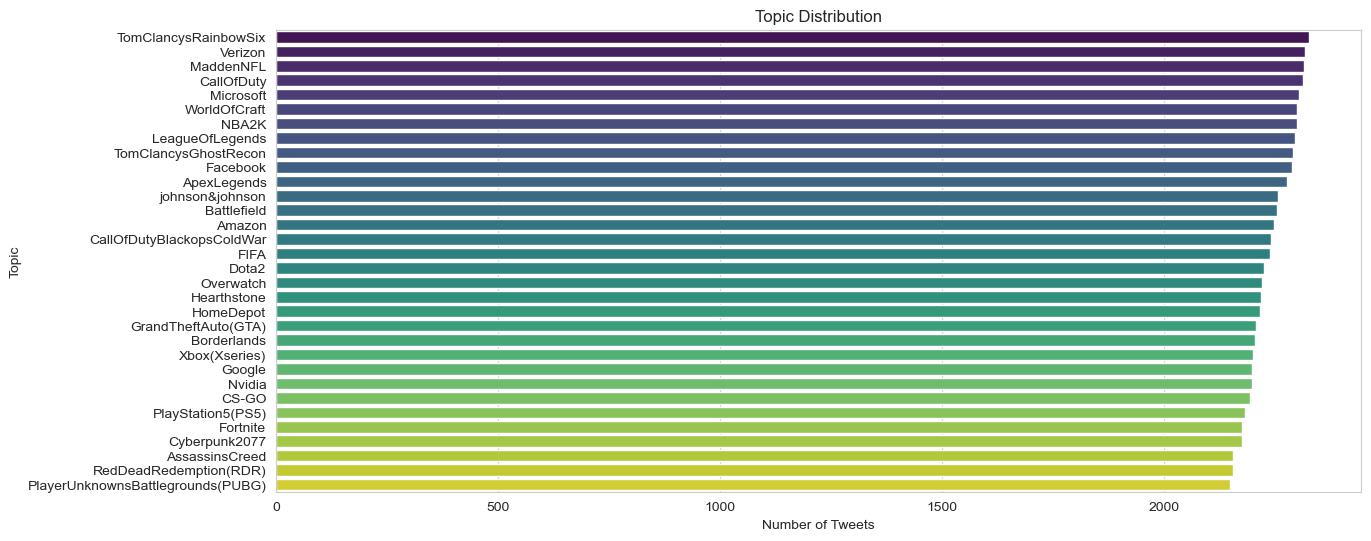

In [43]:
plt.figure(figsize=(14,6))

sns.countplot(
    data=df,
    y="Topic",
    order=df["Topic"].value_counts().index,
    palette="viridis"
)

plt.title("Topic Distribution")
plt.xlabel("Number of Tweets")
plt.ylabel("Topic")

plt.show()

In [44]:
print("Conclusion:")
print("- Some brands or topics receive significantly more tweets.")
print("- Popular topics dominate the dataset.")

Conclusion:
- Some brands or topics receive significantly more tweets.
- Popular topics dominate the dataset.


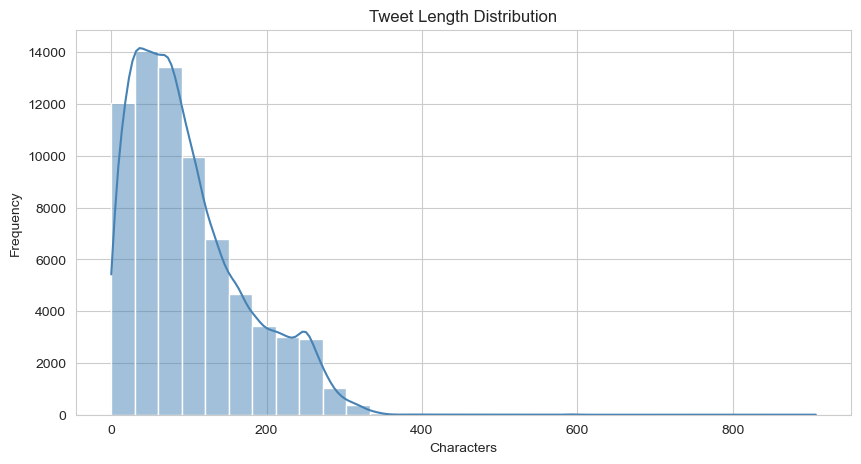

In [45]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Text_Length"],
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Tweet Length Distribution")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.show()

In [46]:
print("Conclusion:")
print("- Most tweets are short.")
print("- Very long tweets are comparatively rare.")

Conclusion:
- Most tweets are short.
- Very long tweets are comparatively rare.


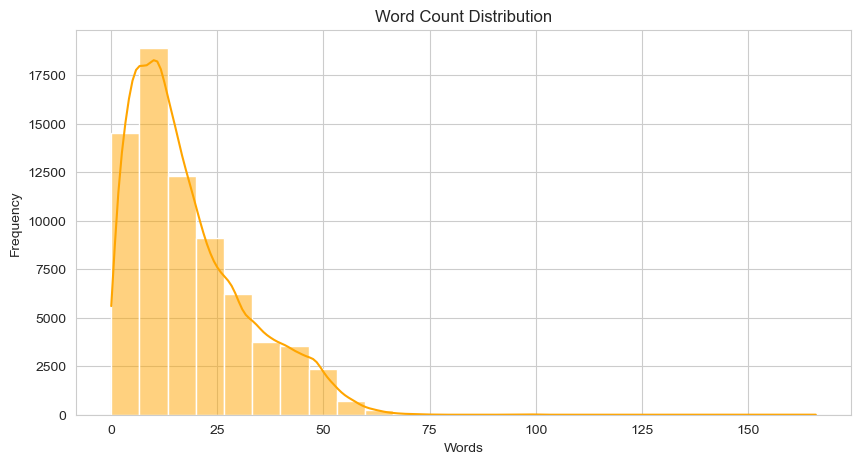

In [47]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Word_Count"],
    bins=25,
    kde=True,
    color="orange"
)

plt.title("Word Count Distribution")

plt.xlabel("Words")

plt.ylabel("Frequency")

plt.show()

In [48]:
print("Conclusion:")
print("- Most tweets contain a small number of words.")
print("- Social media posts are generally concise.")

Conclusion:
- Most tweets contain a small number of words.
- Social media posts are generally concise.


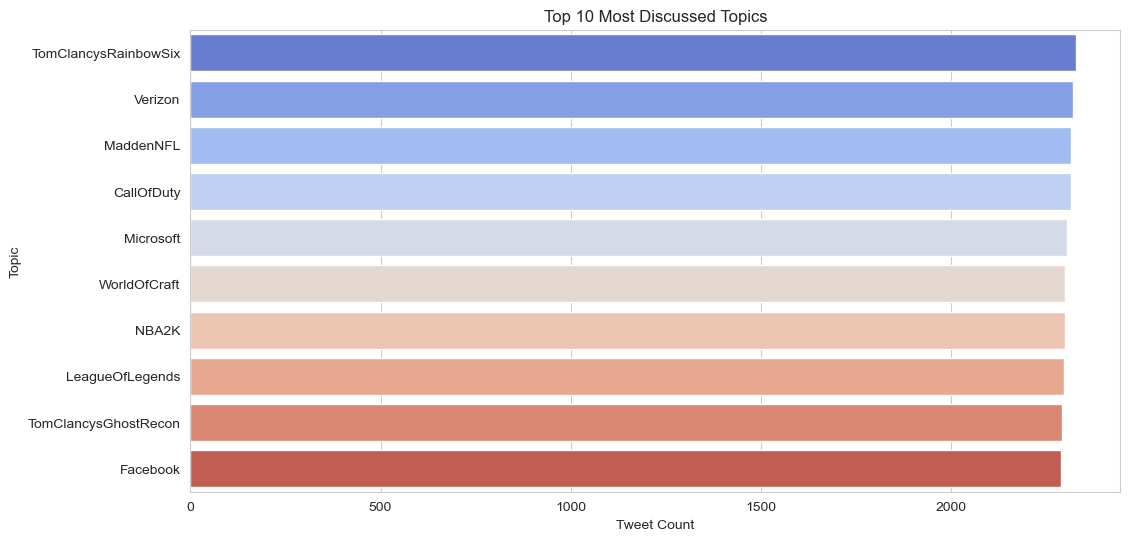

In [49]:
top_topics = df["Topic"].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_topics.values,
    y=top_topics.index,
    palette="coolwarm"
)

plt.title("Top 10 Most Discussed Topics")

plt.xlabel("Tweet Count")

plt.ylabel("Topic")

plt.show()

In [50]:
print("Conclusion:")
print("- These are the most frequently discussed brands or topics.")
print("- They contribute a significant portion of the dataset.")

Conclusion:
- These are the most frequently discussed brands or topics.
- They contribute a significant portion of the dataset.


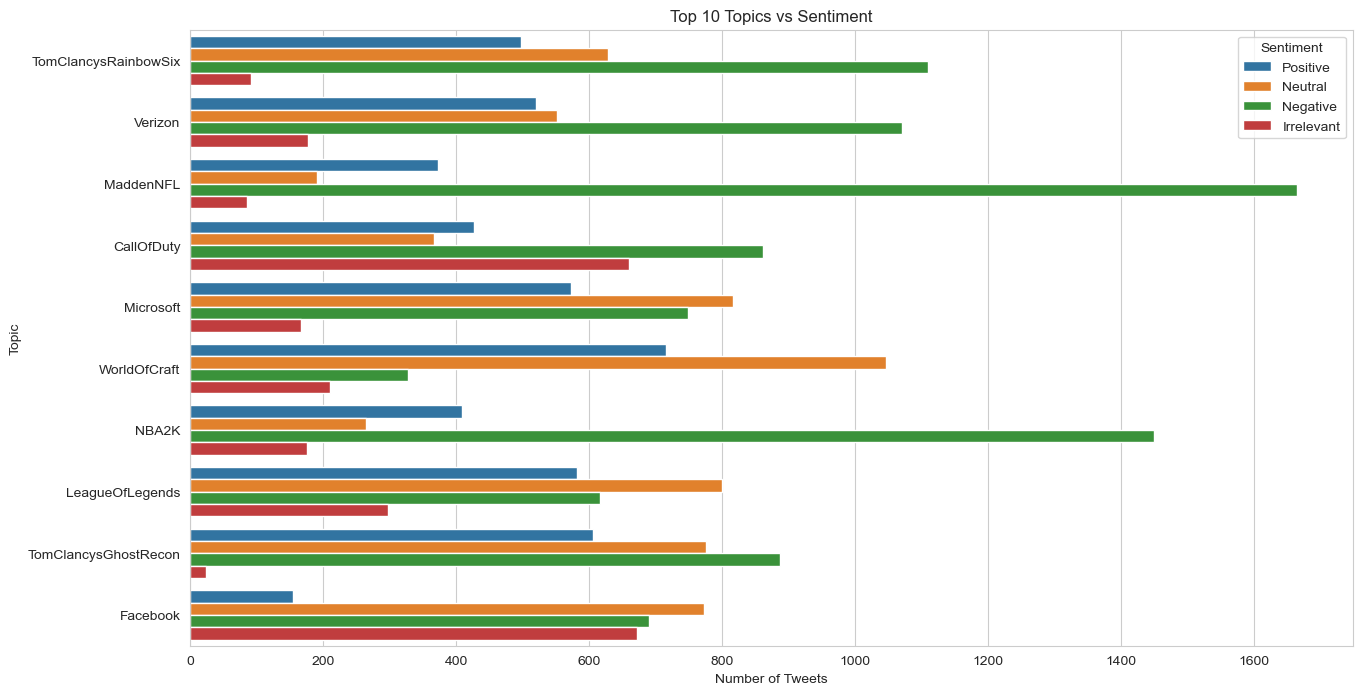

In [51]:
plt.figure(figsize=(15,8))

sns.countplot(
    data=df,
    y="Topic",
    hue="Sentiment",
    order=df["Topic"].value_counts().head(10).index
)

plt.title("Top 10 Topics vs Sentiment")

plt.xlabel("Number of Tweets")

plt.ylabel("Topic")

plt.show()

In [52]:
print("Conclusion:")
print("- Different topics receive different sentiment distributions.")
print("- Some topics have more positive feedback while others receive more criticism.")

Conclusion:
- Different topics receive different sentiment distributions.
- Some topics have more positive feedback while others receive more criticism.


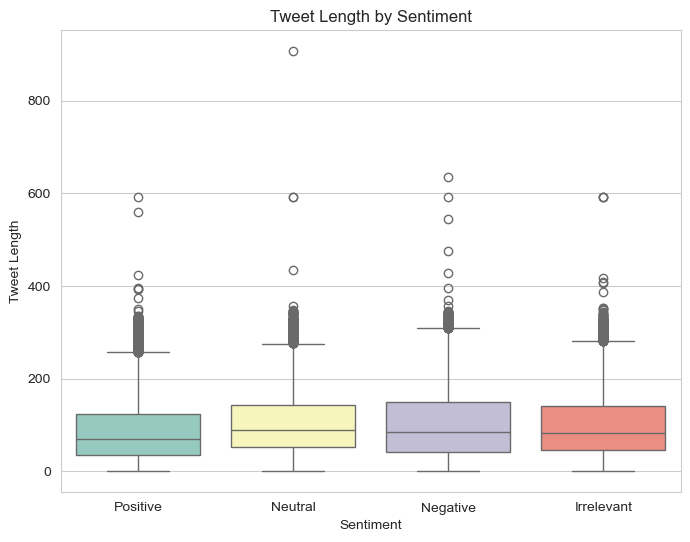

In [53]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="Sentiment",
    y="Text_Length",
    palette="Set3"
)

plt.title("Tweet Length by Sentiment")

plt.xlabel("Sentiment")

plt.ylabel("Tweet Length")

plt.show()

In [54]:
print("Conclusion:")
print("- Negative tweets are sometimes longer than positive tweets.")
print("- Tweet length varies among sentiment classes.")

Conclusion:
- Negative tweets are sometimes longer than positive tweets.
- Tweet length varies among sentiment classes.


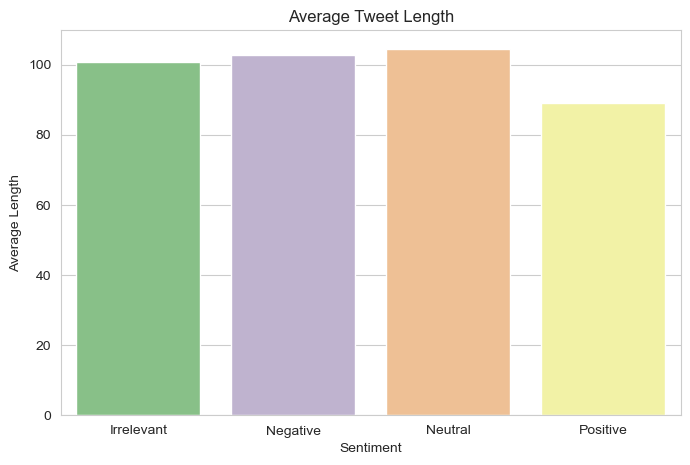

In [55]:
avg_length = df.groupby("Sentiment")["Text_Length"].mean().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(
    data=avg_length,
    x="Sentiment",
    y="Text_Length",
    palette="Accent"
)

plt.title("Average Tweet Length")

plt.xlabel("Sentiment")

plt.ylabel("Average Length")

plt.show()

In [56]:
print("Conclusion:")
print("- Average tweet length differs across sentiment categories.")
print("- This feature may help in sentiment prediction.")

Conclusion:
- Average tweet length differs across sentiment categories.
- This feature may help in sentiment prediction.


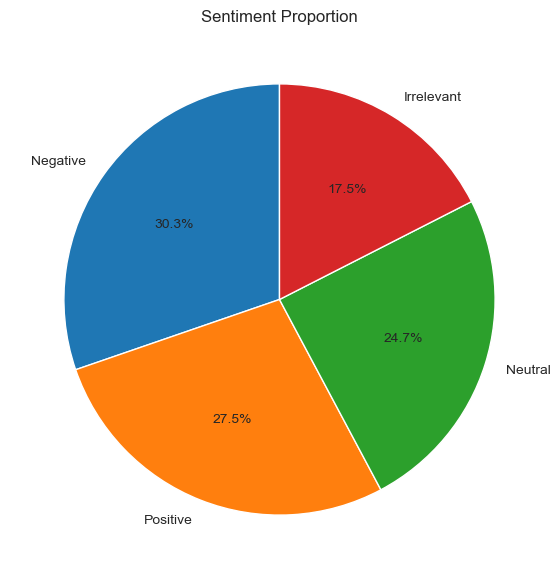

In [57]:
comparison = df["Sentiment"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    comparison.values,
    labels=comparison.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Sentiment Proportion")

plt.show()

In [58]:
print("Conclusion:")
print("- The dataset contains a mix of sentiment classes.")
print("- Class imbalance should be considered during model training.")

Conclusion:
- The dataset contains a mix of sentiment classes.
- Class imbalance should be considered during model training.


In [59]:
print("=" * 60)
print("EDA SUMMARY")
print("=" * 60)

print("""
1. Most tweets belong to a few popular topics.
2. Tweet lengths are generally short.
3. Sentiment distribution is not perfectly balanced.
4. Popular topics receive both positive and negative opinions.
5. Tweet length varies with sentiment.
6. Word count is relatively low for most tweets.
7. Topic is an important feature for sentiment prediction.
8. The dataset is suitable for building a sentiment classification model.
""")

EDA SUMMARY

1. Most tweets belong to a few popular topics.
2. Tweet lengths are generally short.
3. Sentiment distribution is not perfectly balanced.
4. Popular topics receive both positive and negative opinions.
5. Tweet length varies with sentiment.
6. Word count is relatively low for most tweets.
7. Topic is an important feature for sentiment prediction.
8. The dataset is suitable for building a sentiment classification model.



# 5. Feature Engineering

Feature Engineering creates new useful variables from the existing data.

These features help us understand tweet characteristics and improve
machine learning performance.

In [60]:
print("=" * 60)
print("Dataset Columns")
print("=" * 60)

print(df.columns.tolist())

Dataset Columns
['Topic', 'Sentiment', 'Text', 'Clean_Text', 'Text_Length', 'Word_Count', 'Character_Count']


In [61]:
# ==========================================================
# Feature Engineering
# ==========================================================

df["Text_Length"] = df["Clean_Text"].apply(len)

df["Word_Count"] = df["Clean_Text"].apply(
    lambda text: len(text.split())
)

df["Character_Count"] = df["Text"].astype(str).apply(len)

print("Feature Engineering Completed Successfully!")

Feature Engineering Completed Successfully!


In [62]:
df[[
    "Clean_Text",
    "Text_Length",
    "Word_Count",
    "Character_Count"
]].head()

,Clean_Text,Text_Length,Word_Count,Character_Count
0,im getting on borderlands and i will murder yo...,51,10,53
1,i am coming to the borders and i will kill you...,50,12,51
2,im getting on borderlands and i will kill you all,49,10,50
3,im coming on borderlands and i will murder you...,50,10,51
4,im getting on borderlands and i will murder yo...,54,11,57


In [63]:
df[[
    "Text_Length",
    "Word_Count",
    "Character_Count"
]].describe()

,Text_Length,Word_Count,Character_Count
count,71656.000000,71656.000000,71656.000000
mean,99.074369,18.094535,110.538127
std,72.627054,13.495654,79.409848
min,0.000000,0.000000,1.000000
25%,43.000000,8.000000,49.000000
50%,82.000000,15.000000,93.000000
75%,139.000000,26.000000,155.000000
max,907.000000,166.000000,957.000000


In [64]:
print("Conclusion:")
print("- Most tweets are short.")
print("- Word count and text length may help classify sentiment.")

Conclusion:
- Most tweets are short.
- Word count and text length may help classify sentiment.


# 6. Label Encoding

Machine Learning algorithms require numerical values.

Therefore, the sentiment labels are converted into integers.

In [65]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["Sentiment_Label"] = encoder.fit_transform(
    df["Sentiment"]
)

In [66]:
mapping = dict(
    zip(
        encoder.classes_,
        encoder.transform(encoder.classes_)
    )
)

print(mapping)

{'Irrelevant': 0, 'Negative': 1, 'Neutral': 2, 'Positive': 3}


In [67]:
df[[
    "Sentiment",
    "Sentiment_Label"
]].head()

,Sentiment,Sentiment_Label
0,Positive,3
1,Positive,3
2,Positive,3
3,Positive,3
4,Positive,3


# 7. Text Vectorization

Machine Learning models cannot understand text directly.

TF-IDF converts text into numerical vectors by measuring the
importance of each word.

In [68]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

In [69]:
X = tfidf.fit_transform(df["Clean_Text"])

In [70]:
print("TF-IDF Matrix Shape")

print(X.shape)

TF-IDF Matrix Shape
(71656, 5000)


In [71]:
print("Vocabulary Size")

print(len(tfidf.get_feature_names_out()))

Vocabulary Size
5000


In [72]:
print(tfidf.get_feature_names_out()[:50])

['aa' 'aaa' 'aaron' 'ab' 'abandon' 'abilities' 'ability' 'able' 'absolute'
 'absolutely' 'absurd' 'abt' 'abuse' 'abused' 'abusing' 'abusive' 'ac'
 'academy' 'acc' 'accept' 'acceptable' 'access' 'accessible' 'accident'
 'accidentally' 'according' 'account' 'accountable' 'accounts' 'accurate'
 'accused' 'accuses' 'ace' 'acer' 'achieve' 'achieved' 'achievement'
 'achievements' 'acquire' 'acquisition' 'act' 'acting' 'action'
 'activated' 'active' 'actively' 'activision' 'activities' 'actor'
 'actual']


In [73]:
print("Conclusion:")
print("- TF-IDF converts text into numerical vectors.")
print("- Common words receive lower weights.")
print("- Important words receive higher weights.")

Conclusion:
- TF-IDF converts text into numerical vectors.
- Common words receive lower weights.
- Important words receive higher weights.


# 8. Feature Selection

Separate the input features (X)
and the target labels (y).

In [74]:
y = df["Sentiment_Label"]

In [75]:
print("Feature Matrix Shape")

print(X.shape)

print()

print("Target Shape")

print(y.shape)

Feature Matrix Shape
(71656, 5000)

Target Shape
(71656,)


# 9. Train-Test Split

The dataset is divided into training and testing datasets.

Training Data : 80%

Testing Data : 20%

In [76]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)

In [77]:
print("=" * 60)

print("Training Dataset")

print("=" * 60)

print(X_train.shape)

print()

print(y_train.shape)

print()

print("=" * 60)

print("Testing Dataset")

print("=" * 60)

print(X_test.shape)

print()

print(y_test.shape)

Training Dataset
(57324, 5000)

(57324,)

Testing Dataset
(14332, 5000)

(14332,)


In [78]:
print("Training Samples :", len(y_train))

print("Testing Samples :", len(y_test))

print()

print("Training Percentage : 80%")

print("Testing Percentage : 20%")

Training Samples : 57324
Testing Samples : 14332

Training Percentage : 80%
Testing Percentage : 20%


In [79]:
print("=" * 60)

print("DATA PREPARATION SUMMARY")

print("=" * 60)

print(f"Dataset Shape : {df.shape}")

print(f"Vocabulary Size : {len(tfidf.get_feature_names_out())}")

print(f"Training Samples : {len(y_train)}")

print(f"Testing Samples : {len(y_test)}")

print()

print("Data is now ready for Machine Learning.")

DATA PREPARATION SUMMARY
Dataset Shape : (71656, 8)
Vocabulary Size : 5000
Training Samples : 57324
Testing Samples : 14332

Data is now ready for Machine Learning.


# 10. Build Decision Tree Classifier

Decision Trees are supervised machine learning algorithms used for
classification problems.

The model learns decision rules from the training data and predicts
the sentiment of unseen tweets.


In [80]:
# ==========================================================
# Decision Tree Classifier
# ==========================================================

from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

model.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully!")

Decision Tree Model Trained Successfully!


In [81]:
print(model)

DecisionTreeClassifier(criterion='entropy', random_state=42)


# 11. Prediction

The trained model predicts the sentiment of the tweets
from the testing dataset.

In [82]:
# ==========================================================
# Prediction
# ==========================================================

y_pred = model.predict(X_test)

print("Prediction Completed Successfully!")

Prediction Completed Successfully!


In [83]:
comparison = pd.DataFrame({

    "Actual": encoder.inverse_transform(y_test),

    "Predicted": encoder.inverse_transform(y_pred)

})

comparison.head(20)

,Actual,Predicted
0,Positive,Positive
1,Neutral,Negative
2,Positive,Positive
3,Irrelevant,Irrelevant
4,Positive,Positive
5,Negative,Positive
6,Positive,Positive
7,Negative,Negative
8,Neutral,Neutral
9,Negative,Negative


# 12. Model Evaluation

Evaluate the Decision Tree model using standard
classification metrics.

In [84]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy Score")

print("----------------")

print(round(accuracy * 100,2),"%")

Accuracy Score
----------------
75.56 %


In [85]:
precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Precision Score")

print("----------------")

print(round(precision,4))

Precision Score
----------------
0.7581


In [86]:
recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Recall Score")

print("----------------")

print(round(recall,4))

Recall Score
----------------
0.7556


In [87]:
f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("F1 Score")

print("----------------")

print(round(f1,4))

F1 Score
----------------
0.7551


In [88]:
metrics = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score"

    ],

    "Value":[

        accuracy,

        precision,

        recall,

        f1

    ]

})

metrics

,Metric,Value
0,Accuracy,0.755582
1,Precision,0.758146
2,Recall,0.755582
3,F1 Score,0.755120


In [89]:
print(classification_report(

    y_test,

    y_pred,

    target_names=encoder.classes_

))

              precision    recall  f1-score   support

  Irrelevant       0.77      0.66      0.71      2529
    Negative       0.80      0.79      0.79      4383
     Neutral       0.75      0.73      0.74      3543
    Positive       0.70      0.80      0.75      3877

    accuracy                           0.76     14332
   macro avg       0.76      0.75      0.75     14332
weighted avg       0.76      0.76      0.76     14332



In [90]:
print("Conclusion:")

print("- Precision indicates how many predicted sentiments are correct.")

print("- Recall measures how many actual sentiments are identified.")

print("- F1 Score balances Precision and Recall.")

print("- Higher values indicate better classification performance.")

Conclusion:
- Precision indicates how many predicted sentiments are correct.
- Recall measures how many actual sentiments are identified.
- F1 Score balances Precision and Recall.
- Higher values indicate better classification performance.


In [91]:
cm = confusion_matrix(

    y_test,

    y_pred

)

cm

array([[1663,  241,  222,  403],
       [ 167, 3453,  330,  433],
       [ 143,  334, 2597,  469],
       [ 180,  290,  291, 3116]], dtype=int64)

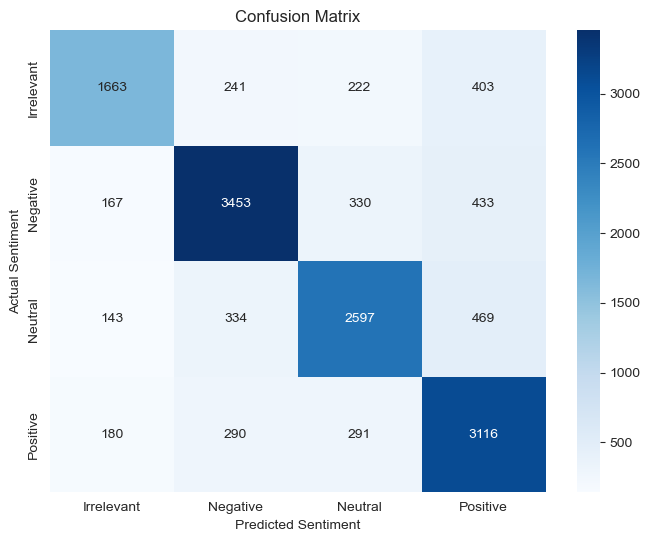

In [92]:
plt.figure(figsize=(8,6))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=encoder.classes_,

    yticklabels=encoder.classes_

)

plt.xlabel("Predicted Sentiment")

plt.ylabel("Actual Sentiment")

plt.title("Confusion Matrix")

plt.show()

In [93]:
print("Conclusion:")

print("- Diagonal values represent correct predictions.")

print("- Off-diagonal values represent incorrect predictions.")

print("- Larger diagonal values indicate better model performance.")

Conclusion:
- Diagonal values represent correct predictions.
- Off-diagonal values represent incorrect predictions.
- Larger diagonal values indicate better model performance.


In [94]:
print("="*60)

print("MODEL PERFORMANCE SUMMARY")

print("="*60)

print(f"Accuracy  : {accuracy:.4f}")

print(f"Precision : {precision:.4f}")

print(f"Recall    : {recall:.4f}")

print(f"F1 Score  : {f1:.4f}")

MODEL PERFORMANCE SUMMARY
Accuracy  : 0.7556
Precision : 0.7581
Recall    : 0.7556
F1 Score  : 0.7551


In [95]:
print("="*60)

print("MODEL INTERPRETATION")

print("="*60)

print("""
1. The Decision Tree successfully classifies tweet sentiments.

2. Accuracy measures the overall correctness of predictions.

3. Precision shows how reliable the predicted sentiments are.

4. Recall measures the model's ability to detect actual sentiments.

5. F1 Score balances Precision and Recall.

6. The model can help organizations monitor public opinion.

7. Businesses can identify negative customer feedback quickly.

8. Positive customer feedback can be used for marketing insights.
""")

MODEL INTERPRETATION

1. The Decision Tree successfully classifies tweet sentiments.

2. Accuracy measures the overall correctness of predictions.

3. Precision shows how reliable the predicted sentiments are.

4. Recall measures the model's ability to detect actual sentiments.

5. F1 Score balances Precision and Recall.

6. The model can help organizations monitor public opinion.

7. Businesses can identify negative customer feedback quickly.

8. Positive customer feedback can be used for marketing insights.



In [96]:
sample = comparison.sample(10)

sample

,Actual,Predicted
5764,Positive,Positive
6044,Positive,Positive
4435,Negative,Negative
13150,Neutral,Negative
12653,Positive,Positive
3649,Negative,Positive
8134,Positive,Positive
1571,Neutral,Neutral
12005,Positive,Positive
8534,Positive,Positive


In [97]:
print("="*60)

print("PART 4 SUMMARY")

print("="*60)

print("✔ Decision Tree Model Built")

print("✔ Predictions Generated")

print("✔ Accuracy Calculated")

print("✔ Precision Calculated")

print("✔ Recall Calculated")

print("✔ F1 Score Calculated")

print("✔ Confusion Matrix Created")

print("✔ Classification Report Generated")

print("✔ Model Successfully Evaluated")

PART 4 SUMMARY
✔ Decision Tree Model Built
✔ Predictions Generated
✔ Accuracy Calculated
✔ Precision Calculated
✔ Recall Calculated
✔ F1 Score Calculated
✔ Confusion Matrix Created
✔ Classification Report Generated
✔ Model Successfully Evaluated


# 13. Feature Importance

Feature Importance helps us identify the most influential words
used by the Decision Tree while predicting tweet sentiment.

In [98]:
# ==========================================================
# Feature Importance
# ==========================================================

feature_importance = pd.DataFrame({
    "Feature": tfidf.get_feature_names_out(),
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
1685,fix,0.012839
2365,just,0.010145
2599,love,0.009485
1809,game,0.008589
2514,like,0.008256
1901,good,0.007975
2339,johnson,0.007951
406,best,0.007064
2977,occurred,0.006958
144,amazon,0.006428


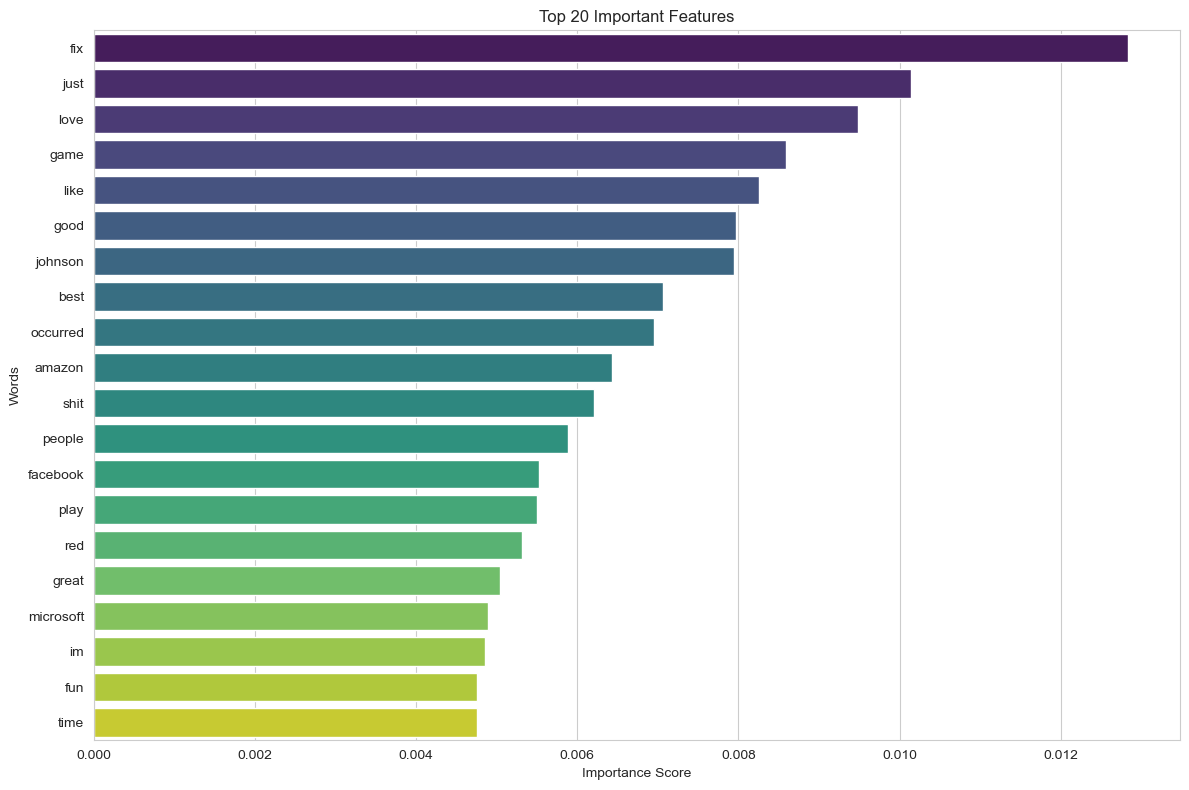

In [99]:
plt.figure(figsize=(12,8))

top_features = feature_importance.head(20)

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 20 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Words")

plt.tight_layout()

plt.show()

In [100]:
print("Conclusion:")
print("- These words have the highest impact on sentiment prediction.")
print("- They play an important role in separating positive, negative, neutral, and irrelevant tweets.")

Conclusion:
- These words have the highest impact on sentiment prediction.
- They play an important role in separating positive, negative, neutral, and irrelevant tweets.


# 14. Save Cleaned Dataset

The cleaned dataset is saved for future analysis and model building.

In [101]:
df.to_csv(
    "cleaned_twitter_sentiment.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [102]:
df.head()

,Topic,Sentiment,Text,Clean_Text,Text_Length,Word_Count,Character_Count,Sentiment_Label
0,Borderlands,Positive,im getting on borderlands and i will murder yo...,im getting on borderlands and i will murder yo...,51,10,53,3
1,Borderlands,Positive,I am coming to the borders and I will kill you...,i am coming to the borders and i will kill you...,50,12,51,3
2,Borderlands,Positive,im getting on borderlands and i will kill you ...,im getting on borderlands and i will kill you all,49,10,50,3
3,Borderlands,Positive,im coming on borderlands and i will murder you...,im coming on borderlands and i will murder you...,50,10,51,3
4,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,im getting on borderlands and i will murder yo...,54,11,57,3


In [103]:
# 15. Final Summary

This section summarizes the entire sentiment analysis project.

SyntaxError: invalid syntax (4193079236.py, line 3)